In [4]:
# pip install seaborn

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (10, 6)

sns.set_theme(style="whitegrid")

In [6]:
PALETTE = [
    "#D6A4A4",  # Dusty Rose
    "#C6B69D",  # Warm Beige
    "#88728D",  # Mauve
    "#6F859C",  # Slate Blue
    "#4A5659"   # Charcoal
]

sns.set_palette(PALETTE)

In [11]:
products_df = pd.read_csv("/Users/gabrielaslomiany/GIT/Sephora/data/product_info.csv")
reviews_df = pd.read_csv("/Users/gabrielaslomiany/GIT/Sephora/data/reviews.csv")
products_df.head()

/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_8709/4238109149.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_df = pd.read_csv("/Users/gabrielaslomiany/GIT/Sephora/data/reviews.csv")


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,NaN,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) D-Limonene, Linalool, Benzyl Salicylate, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Benzl Benzoate, Citral, Geraniol, Eugenol, Benzyl Alcohol, Farnesol, Citronellol, Isoeugenol.', 'Invisible Post Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Ethylhexyl Methoxycinnamate, Ethylhexyl Salicylate, Butyl Methoxydibenzoylmethane, Benzyl Benzoate, Citral, Coumarin, Limonene, Alpha-Isomethyl Ionone, Linalool.', 'Kashbah Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Coumarin, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, D-Limonene, Eugenol, Linalool, Citronellol, Geraniol, Cinnamal, Citral.', 'L’Air Barbes Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Benzyl Salicylate, D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Linalool Citral, Alphaisomethyl Ionone, Benzyl Benzoate, Geraniol Farnesol, Isoeugenol, Eugenol.', 'La Habana Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Ethylhexyl Methoxycinnamate, Ethylhexyl Salicylate, Butyl Methoxydibenzoylmethane, Benzyl Alcohol, Benzyl Benzoate, Benzyl Cinnamate, Cinnamal, Citral, Coumarin Limonene, Eugenol, Alpha-Isomethyl Ionone, Linalool.', 'Purple Haze Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Octoxynol-10, D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Geraniol, Linalool, Coumarin, Farnesol, Eugenol, Citral.', 'Rainbow Bar Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Hexyl Cinnamal, Citronellol, Linalool, Coumarin, Eugenol, Citral, Isoeugenol, Geraniol.']",35.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scent', 'Woody & Earthy Scent', 'Fresh Scent']",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Ethylhexyl Methoxycinnamate, Ethylhexyl Salicylate, Butyl Methoxydibenzoylmethane, Benzyl Alcohol, Benzyl Benzoate, Benzyl Cinnamate, Cinnamal, Citral, Coumarin Limonene, Eugenol, Alpha-Isomethyl Ionone, Linalool.']",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent', 'Warm &Spicy Scent']",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Hexyl Cinnamal Citronellol, Linalool, Coumarin, Eugenol, Citral, Isoeugenol, Geraniol.']",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent', 'Woody & Earthy Scent']",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Coumarin, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, D-Limonene, Eugenol, Linalool, Citronellol, Geraniol, Cinnamal, Citral.']",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent', 'Warm &Spicy Scent']",Fragranc

In [12]:
reviews_df.head()

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,"I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil based and removes all of your makeup super easily. I follow-up with this water based cleanser, and I also use this just by itself when I’m not wearing make-up. It leaves the skin gently cleansed, but without stripping the skin. 10/10 recommend combining with the make-up melt. It’s perfection!",Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,"I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.",Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and apply lip balm daily but nothing helped until I started using this. untiluntistafted usinf this.,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the texture. Gummy Bear is my second most favourite scent. Grapefruit is the best in my opinion.,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must have. After a few weeks of use I have learned I will always have by my bedside. I thought it was a little expensive but a little goes a long way. It is worth the price.",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0


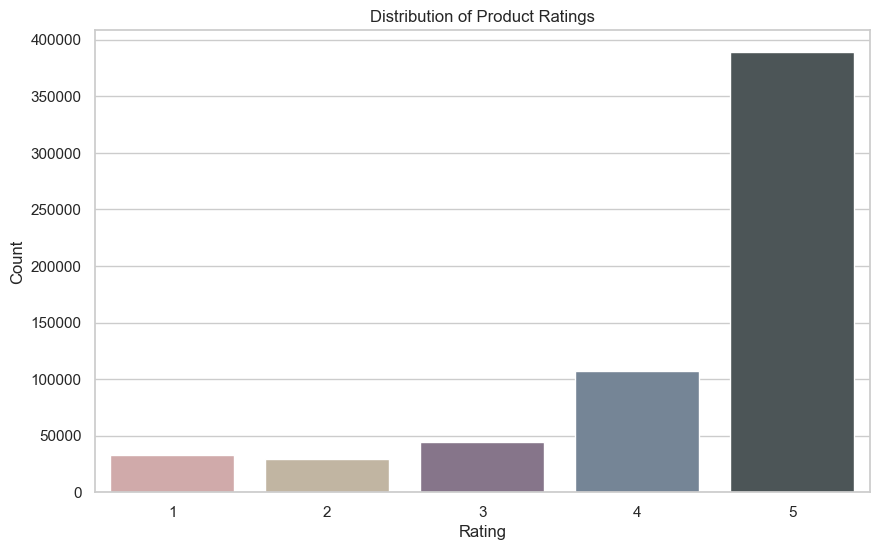

In [24]:
sns.countplot(data=reviews_df, x="rating", hue="rating", palette=PALETTE, legend=False)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()